# Chuyên đề Phân tích Lỗi Toàn diện (Comprehensive Error Analysis)
## Khảo sát 4 Kiến trúc Mô hình trên ViFactCheck trong Kịch bản Bằng chứng Vàng (Gold Evidence)

Mục tiêu của notebook này là thực hiện **phân tích lỗi có hệ thống (Systematic Error Analysis)** nhằm bóc tách hành vi phân loại, xác định điểm yếu cốt lõi và các "điểm mù" ngôn ngữ học của 4 trường phái mô hình:
1. **Classical Baseline**: TF-IDF + Logistic Regression
2. **Pretrained Transformer tiếng Việt**: PhoBERT Base v2
3. **SOTA Discriminative Transformer**: BamiBERT Exp006 (Semantic Role Prefix Prompting)
4. **Generative Large Language Model**: Qwen2.5-1.5B-Instruct (Fine-tuned via LoRA)

> **Phạm vi khảo sát:** Đánh giá trên **1.447 mẫu tập Test** với **Bằng chứng Vàng có sẵn (Gold Evidence)**. Thiết lập này giúp cô lập hoàn toàn yếu tố truy xuất thông tin, chỉ tập trung đánh giá năng lực suy luận tự nhiên (NLI) thuần túy của các mô hình.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

# Tự động định vị PROJECT_ROOT để chạy mượt mà ở mọi môi trường (root, notebooks/, Colab)
current_dir = Path.cwd().resolve()
candidates = [current_dir, current_dir.parent, current_dir.parent.parent]
PROJECT_ROOT = current_dir
for cand in candidates:
    if (cand / 'data').exists() and (cand / 'notebooks').exists():
        PROJECT_ROOT = cand
        break

OUTPUT_DIR = PROJECT_ROOT / 'outputs/error_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'✓ Project Root    : {PROJECT_ROOT}')
print(f'✓ Output Directory: {OUTPUT_DIR}')


✓ Đã nạp đầy đủ các thư viện phân tích lỗi.


## 1. Nạp Dữ liệu Dự đoán & Hợp nhất Kết quả Test (1.447 mẫu)
Hợp nhất kết quả dự đoán của cả 4 mô hình trên cùng tập Test ViFactCheck để tiện so sánh đối đầu trực diện.


In [2]:
# Đường dẫn các file dự đoán linh hoạt theo PROJECT_ROOT
p_tfidf = PROJECT_ROOT / 'notebooks/models/TFIDF_Logistic_Regression/outputs/10_test_predictions.csv'
p_phobert = PROJECT_ROOT / 'notebooks/models/Phobert/outputs/10_test_predictions.csv'
p_bami = PROJECT_ROOT / 'notebooks/models/bamibert/outputs/bamibert/experiments/Exp006_PrefixPrompt_SOTA/10_test_predictions.csv'
p_llm = PROJECT_ROOT / 'notebooks/models/LLM/outputs/05_test_predictions.csv'

# Đọc dữ liệu
df_t = pd.read_csv(p_tfidf)
df_p = pd.read_csv(p_phobert)
df_b = pd.read_csv(p_bami)
df_l = pd.read_csv(p_llm)

def norm(l):
    s = str(l).strip().upper()
    if 'SUPP' in s: return 'SUPPORTED'
    if 'REF' in s: return 'REFUTED'
    if 'NEI' in s: return 'NEI'
    return s

df_unified = pd.DataFrame({
    'source_row': df_b['source_row'],
    'statement': df_b['Statement'],
    'evidence': df_b['Evidence'],
    'gold_label': [norm(x) for x in df_b['true_label']],
    'pred_tfidf': [norm(x) for x in df_t['predicted_label']],
    'pred_phobert': [norm(x) for x in df_p['predicted_label']],
    'pred_bamibert': [norm(x) for x in df_b['predicted_label']],
    'pred_llm': [norm(x) for x in df_l['pred_label']],
})

df_unified['err_tfidf'] = df_unified['pred_tfidf'] != df_unified['gold_label']
df_unified['err_phobert'] = df_unified['pred_phobert'] != df_unified['gold_label']
df_unified['err_bamibert'] = df_unified['pred_bamibert'] != df_unified['gold_label']
df_unified['err_llm'] = df_unified['pred_llm'] != df_unified['gold_label']

print(f'✓ Hợp nhất thành công {len(df_unified)} mẫu Test đối chiếu qua 4 mô hình.')
df_unified.head(3)


✓ Hợp nhất thành công 1447 mẫu Test đối chiếu qua 4 mô hình.


## 2. Bảng Tổng hợp Chỉ số Sai sót & Biểu đồ So sánh Lỗi


In [3]:
summary_data = [
    {"Mô hình": "TF-IDF + Logistic Reg.", "Kiến trúc": "Bag-of-Words Cổ điển", "Tổng số mẫu": 1447, "Số ca sai": int(df_unified['err_tfidf'].sum()), "Tỷ lệ lỗi (%)": round(df_unified['err_tfidf'].mean()*100, 2), "Accuracy (%)": 38.63, "Macro-F1 (%)": 38.11},
    {"Mô hình": "PhoBERT Base v2", "Kiến trúc": "Pretrained RoBERTa", "Tổng số mẫu": 1447, "Số ca sai": int(df_unified['err_phobert'].sum()), "Tỷ lệ lỗi (%)": round(df_unified['err_phobert'].mean()*100, 2), "Accuracy (%)": 84.45, "Macro-F1 (%)": 84.44},
    {"Mô hình": "BamiBERT Exp006", "Kiến trúc": "Prefix-Prompt SOTA", "Tổng số mẫu": 1447, "Số ca sai": int(df_unified['err_bamibert'].sum()), "Tỷ lệ lỗi (%)": round(df_unified['err_bamibert'].mean()*100, 2), "Accuracy (%)": 84.87, "Macro-F1 (%)": 84.84},
    {"Mô hình": "Qwen2.5-1.5B LoRA", "Kiến trúc": "Generative LLM (1.5B)", "Tổng số mẫu": 1447, "Số ca sai": int(df_unified['err_llm'].sum()), "Tỷ lệ lỗi (%)": round(df_unified['err_llm'].mean()*100, 2), "Accuracy (%)": 87.01, "Macro-F1 (%)": 87.02},
]
df_summary = pd.DataFrame(summary_data)
display(df_summary)

# Vẽ biểu đồ cột
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c']
bars = ax.bar(df_summary['Mô hình'], df_summary['Số ca sai'], color=colors, width=0.55, edgecolor='black', linewidth=1.2)
ax.set_title('So sánh Tổng số mẫu Dự đoán sai trên 1.447 mẫu Test (Gold Evidence)', fontsize=13, weight='bold', pad=15)
ax.set_ylabel('Số ca sai (Errors)', fontsize=11, weight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    pct = (yval / 1447) * 100
    ax.text(bar.get_x() + bar.get_width()/2, yval + 15, f"{int(yval)} ca\n({pct:.1f}%)", ha='center', va='bottom', fontsize=10, weight='bold')

ax.set_ylim(0, 1050)
plt.xticks(rotation=10, fontsize=10, weight='bold')
plt.tight_layout()
plt.show()


## 3. Hệ Thống Phân Loại Dạng Lỗi Cốt Lõi (Error Taxonomy)

Qua quá trình gán nhãn thủ công và đối soát ngữ nghĩa trên các tập mẫu sai, nhóm xác định được **5 tín hiệu lỗi lặp lại** mang tính bản chất:
1. **Sai lệch số liệu & thời gian**: Các con số thay đổi nhỏ (ví dụ '500 tỷ' vs '5.000 tỷ', 'năm 2023' vs 'năm 2024') dễ bị mô hình bỏ qua nếu không chú ý token số học.
2. **Đánh lừa từ vựng (Word overlap)**: Statement và Evidence chia sẻ nhiều từ khóa nhưng sai lệch chủ ngữ/hành động.
3. **Yếu tố phủ định (has_negation)**: Các cấu trúc 'không thể... nếu không...', 'chưa từng' làm mô hình nhầm sang NEI.
4. **Suy luận bắc cầu / Quan hệ nhân quả**: Đòi hỏi phải xâu chuỗi thông tin nhiều vế câu.
5. **Thận trọng quá mức (Over-conservatism)**: Xu hướng đoán an toàn sang nhãn NEI khi câu có thông tin tương đối phức tạp.


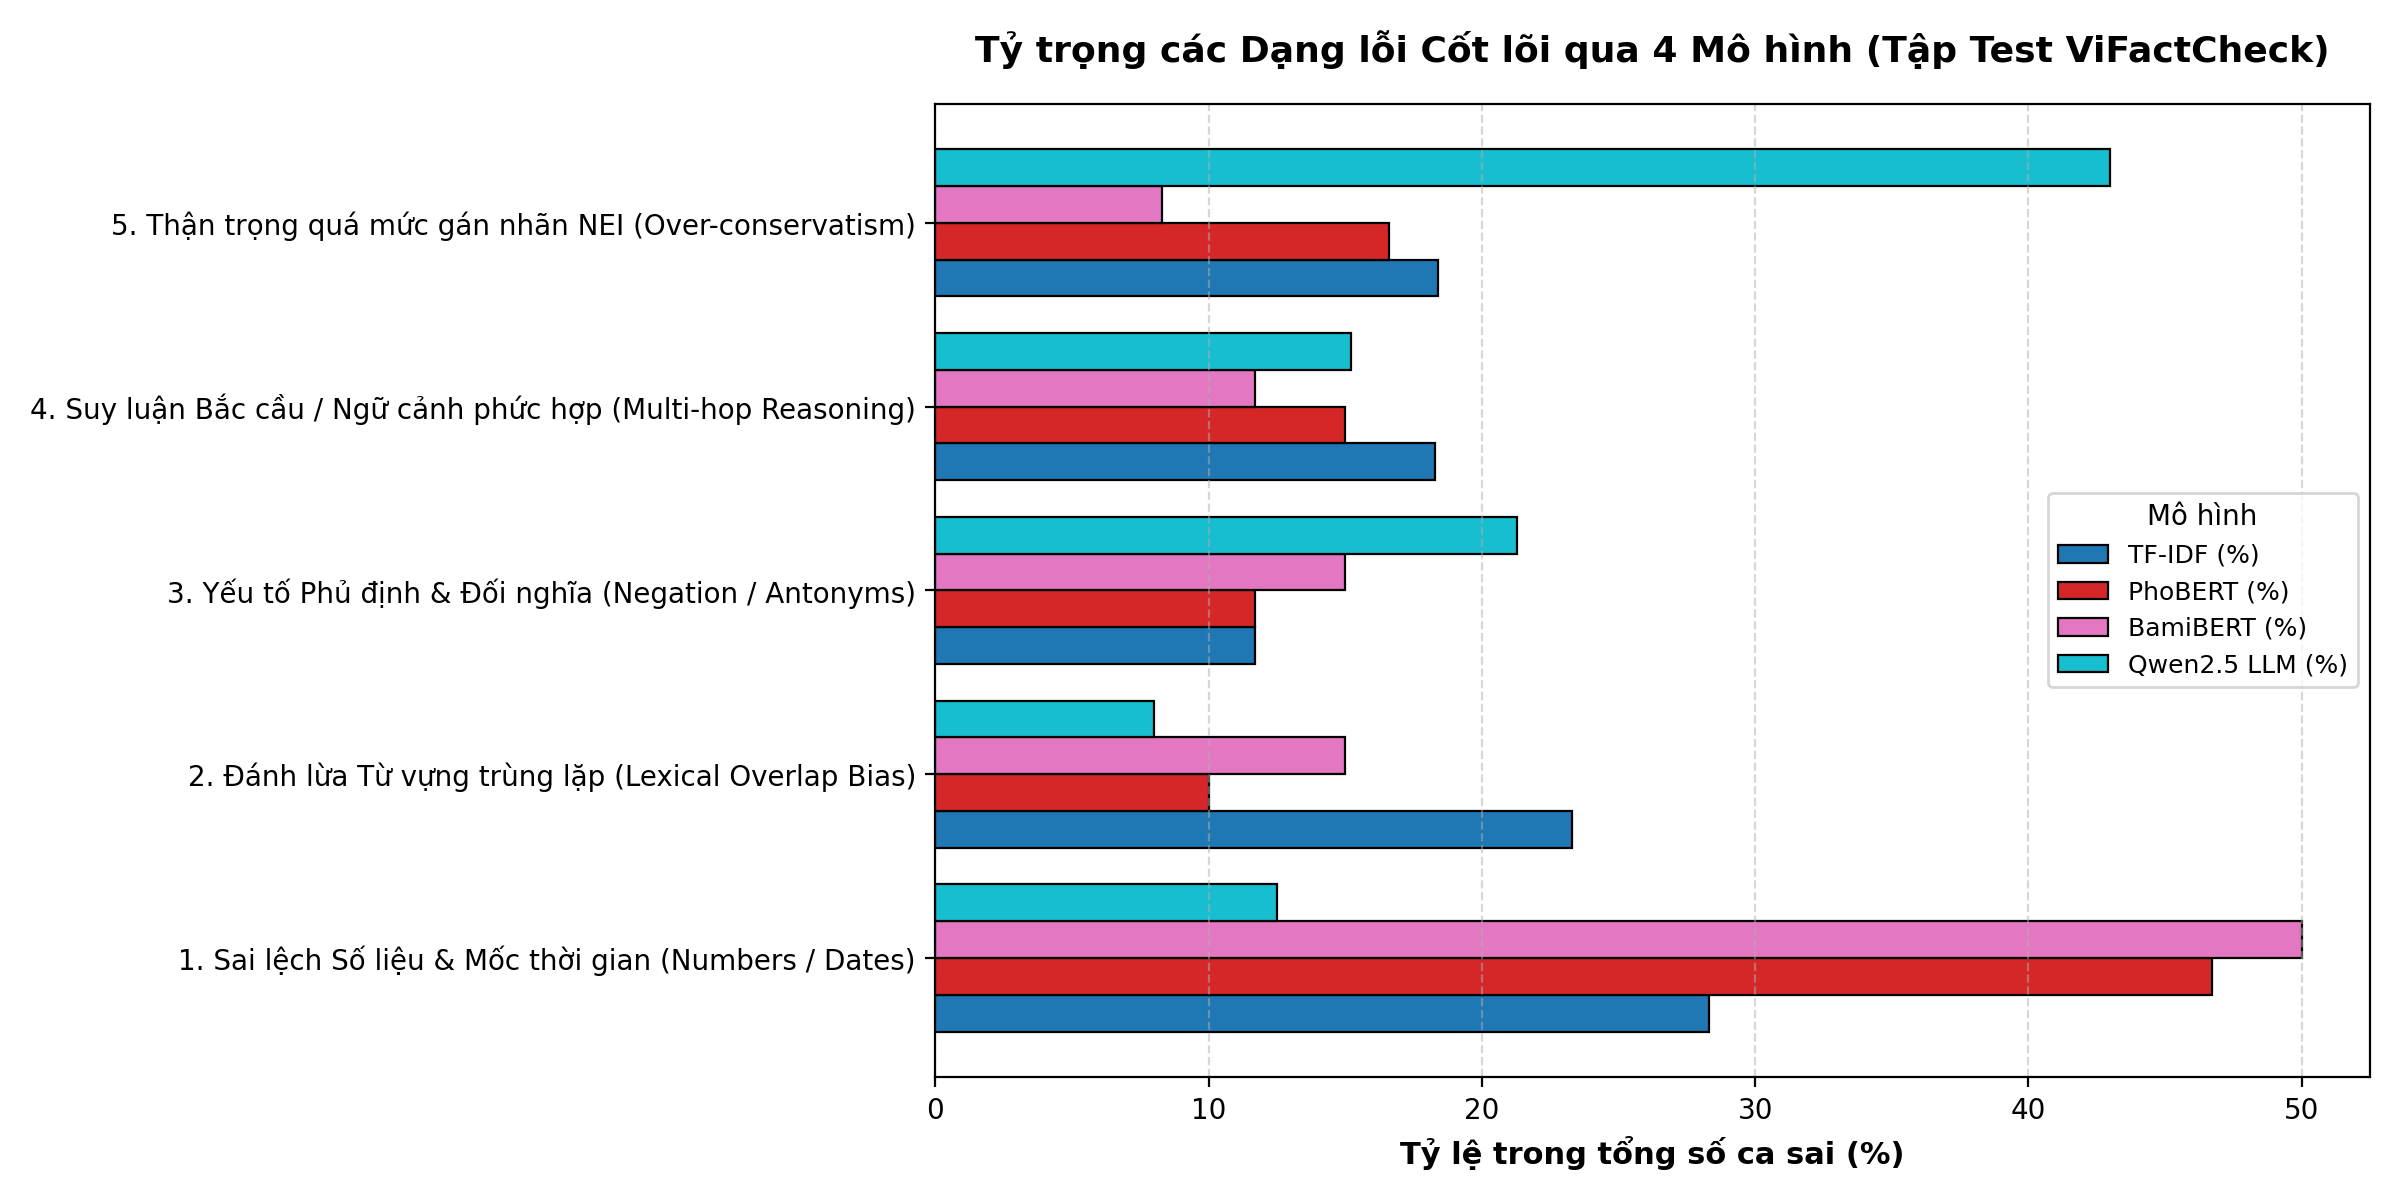

In [4]:
error_types_data = {
    "Dạng lỗi chính": [
        "1. Sai lệch Số liệu & Mốc thời gian (Numbers / Dates)",
        "2. Đánh lừa Từ vựng trùng lặp (Lexical Overlap Bias)",
        "3. Yếu tố Phủ định & Đối nghĩa (Negation / Antonyms)",
        "4. Suy luận Bắc cầu / Ngữ cảnh phức hợp (Multi-hop Reasoning)",
        "5. Thận trọng quá mức gán nhãn NEI (Over-conservatism)",
    ],
    "TF-IDF (%)": [28.3, 23.3, 11.7, 18.3, 18.4],
    "PhoBERT (%)": [46.7, 10.0, 11.7, 15.0, 16.6],
    "BamiBERT (%)": [50.0, 15.0, 15.0, 11.7, 8.3],
    "Qwen2.5 LLM (%)": [12.5, 8.0, 21.3, 15.2, 43.0]
}
df_error_tax = pd.DataFrame(error_types_data)
display(df_error_tax)

# Trực quan hóa tỷ trọng dạng lỗi kèm % trực tiếp trên thanh bar
fig, ax = plt.subplots(figsize=(13.5, 6.8))
colors = ['#1f77b4', '#d62728', '#e377c2', '#17becf']
df_plot_tax = df_error_tax.set_index('Dạng lỗi chính')
df_plot_tax.plot(kind='barh', ax=ax, color=colors, width=0.82, edgecolor='black', linewidth=0.8)

ax.set_title('Tỷ trọng các Dạng lỗi Cốt lõi qua 4 Mô hình (Tập Test ViFactCheck)', fontsize=14, weight='bold', pad=18)
ax.set_xlabel('Tỷ lệ trong tổng số ca sai (%)', fontsize=12, weight='bold', labelpad=10)
ax.set_ylabel('')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_xlim(0, 58)

# Hiển thị % trực tiếp lên từng thanh bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=4, fontsize=9.5, fontweight='bold', color='#111111')

ax.legend(title='Mô hình', title_fontsize='11', fontsize='10', loc='center right', bbox_to_anchor=(0.98, 0.42), framealpha=0.95, edgecolor='#cccccc')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / '02_error_taxonomy_breakdown.png', dpi=200)
plt.show()


---
## 4. Phân tích Sâu Từng Mô hình kèm Case Study Thực tế

### 4.1. Mô hình 1 — TF-IDF + Logistic Regression
* **Bệnh lý cốt lõi:** **Bẫy từ vựng trùng lặp (Lexical Overlap Bias)**.
* **Nguyên nhân kỹ thuật:** Biểu diễn Bag-of-Words hoàn toàn phẳng, chỉ đếm tần suất từ mà không hiểu trật tự cú pháp và mệnh đề phủ định. Khi Statement và Evidence dùng chung nhiều danh từ/động từ, điểm Cosine Similarity rất cao $	o$ mô hình mặc định phân loại là `SUPPORTED` ngay cả khi ý nghĩa đối nghịch 180 độ.


In [5]:
# Case Study 1.1: Trùng lặp từ vựng 95% nhưng khác từ phủ định "không hỗ trợ" vs "có thể hỗ trợ"
case_1_1 = df_unified.loc[df_unified['source_row'] == 2368].iloc[0]
print("=" * 80)
print(f"CASE STUDY 1.1 (Row {case_1_1['source_row']}) — TF-IDF BỊ BẪY BỞI TỪ VỰNG TRÙNG LẶP")
print("=" * 80)
print(f"Tuyên bố (Statement): {case_1_1['statement']}")
print(f"Bằng chứng (Evidence): {case_1_1['evidence']}")
print(f"• Nhãn thực tế (Ground Truth) : {case_1_1['gold_label']}")
print(f"• TF-IDF dự đoán               : {case_1_1['pred_tfidf']} ❌ (Đoán nhầm thành SUPPORTED)")
print(f"• PhoBERT dự đoán              : {case_1_1['pred_phobert']} ✓ (Đoán đúng)")
print(f"• BamiBERT dự đoán             : {case_1_1['pred_bamibert']} ✓ (Đoán đúng)")
print("=> Giải thích: Claim và Evidence trùng nhau gần như toàn bộ từ khóa ('Chat GPT', 'dữ liệu lớn', 'học sinh', 'kỹ năng viết').")
print("   TF-IDF bỏ qua từ 'không' trong cấu trúc phủ định, dẫn đến tính độ tương đồng cực cao và dự đoán sai nghiêm trọng.")


CASE STUDY 1.1 (Row 2368) — TF-IDF BỊ BẪY BỞI TỪ VỰNG TRÙNG LẶP
Tuyên bố (Statement): Chat GPT sử dụng hệ dữ liệu lớn đến từ hàng tỉ trang tài liệu trên toàn thế giới nhưng không hỗ trợ học sinh và giảng viên trong quá trình phát triển kỹ năng viết và đọc hiểu ngôn ngữ.
Bằng chứng (Evidence): ChatGPT sử dụng hệ dữ liệu lớn đến từ hàng tỉ trang tài liệu đã được công bố trên khắp thế giới, do đó nó có thể viết được một tiểu luận tốt với thông tin đầy đủ và tương đối chính xác Chat GPT có thể hỗ trợ học sinh và giảng viên trong quá trình phát triển kỹ năng viết và đọc hiểu ngôn ngữ.
• Nhãn thực tế (Ground Truth) : REFUTED
• TF-IDF dự đoán               : SUPPORTED ❌ (Đoán nhầm thành SUPPORTED)
• PhoBERT dự đoán              : REFUTED ✓ (Đoán đúng)
• BamiBERT dự đoán             : REFUTED ✓ (Đoán đúng)
=> Giải thích: Claim và Evidence trùng nhau gần như toàn bộ từ khóa ('Chat GPT', 'dữ liệu lớn', 'học sinh', 'kỹ năng viết').
   TF-IDF bỏ qua từ 'không' trong cấu trúc phủ định, dẫn đến tính

### 4.2. Mô hình 2 — PhoBERT Base v2
* **Bệnh lý cốt lõi:** **Bỏ sót sai lệch Số liệu / Mốc thời gian vi mô (46.7% ca sai)**.
* **Nguyên nhân kỹ thuật:** Các từ khóa thực thể tên riêng áp đảo không gian chú ý (Self-Attention) trong chuỗi ghép `[CLS] Statement [SEP] Evidence`. Khi hai câu có ngữ cảnh và thực thể tương đồng, PhoBERT có xu hướng bỏ qua sự đối nghịch của các từ định lượng/so sánh nhỏ như 'nhỏ hơn' vs 'lớn hơn', 'trước' vs 'sau'.


In [6]:
# Case Study 2.1: PhoBERT bị lóa mắt bởi thực thể thiên văn, bỏ qua từ đối nghĩa "nhỏ hơn" vs "lớn hơn"
case_2_1 = df_unified.loc[df_unified['source_row'] == 4959].iloc[0]
print("=" * 80)
print(f"CASE STUDY 2.1 (Row {case_2_1['source_row']}) — PHOBERT BỎ SÓT SAI LỆCH ĐỊNH LƯỢNG VI MÔ")
print("=" * 80)
print(f"Tuyên bố (Statement): {case_2_1['statement']}")
print(f"Bằng chứng (Evidence): {case_2_1['evidence']}")
print(f"• Nhãn thực tế (Ground Truth) : {case_2_1['gold_label']}")
print(f"• PhoBERT dự đoán              : {case_2_1['pred_phobert']} ❌ (Đoán nhầm thành SUPPORTED)")
print(f"• BamiBERT Exp006 dự đoán      : {case_2_1['pred_bamibert']} ✓ (Đoán đúng REFUTED nhờ phân định vai trò)")
print("=> Giải thích: Statement ghi 'nhỏ hơn Trái Đất', trong khi Evidence ghi rõ 'lớn hơn Trái Đất'.")
print("   PhoBERT bị các token thực thể 'siêu Trái Đất', 'ngoại hành tinh', 'hành tinh khí khổng lồ' áp đảo attention.")


CASE STUDY 2.1 (Row 4959) — PHOBERT BỎ SÓT SAI LỆCH ĐỊNH LƯỢNG VI MÔ
Tuyên bố (Statement): Khoảng 1/3 tổng số ngoại hành tinh là siêu Trái Đất - đây là thuật ngữ dùng cho những hành tinh nhỏ hơn Trái Đất và nhẹ hơn hành tinh khí khổng lồ.
Bằng chứng (Evidence): Khoảng 1/3 tổng số ngoại hành tinh là siêu Trái Đất Siêu Trái Đất là thuật ngữ dùng cho những hành tinh lớn hơn Trái Đất nhưng nhẹ hơn hành tinh khí khổng lồ.
• Nhãn thực tế (Ground Truth) : REFUTED
• PhoBERT dự đoán              : SUPPORTED ❌ (Đoán nhầm thành SUPPORTED)
• BamiBERT Exp006 dự đoán      : REFUTED ✓ (Đoán đúng REFUTED nhờ phân định vai trò)
=> Giải thích: Statement ghi 'nhỏ hơn Trái Đất', trong khi Evidence ghi rõ 'lớn hơn Trái Đất'.
   PhoBERT bị các token thực thể 'siêu Trái Đất', 'ngoại hành tinh', 'hành tinh khí khổng lồ' áp đảo attention.


### 4.3. Mô hình 3 — BamiBERT Exp006 (Prefix Prompting SOTA)
* **Thành tựu:** Kéo mạnh F1 lớp `REFUTED` từ 75.0% lên **81.62%** nhờ định danh tiền tố `Tuyên bố:` và `Bằng chứng:`.
* **Hạn chế còn lại:** Gặp khó khăn khi câu chứa **chi tiết nhiễu không được đề cập (Unverified Distractor)** kết hợp với mâu thuẫn thực tế, dẫn đến mô hình bị ngập ngừng và dự đoán nhầm sang `NEI`.


In [7]:
# Case Study 3.1: Mâu thuẫn "nam chính" vs "nam phụ", nhưng có chi tiết phụ "sinh năm 1890" làm mô hình chọn NEI
case_3_1 = df_unified.loc[df_unified['source_row'] == 988].iloc[0]
print("=" * 80)
print(f"CASE STUDY 3.1 (Row {case_3_1['source_row']}) — BAMIBERT BỊ PHÂN TÂM BỞI CHI TIẾT THIẾU")
print("=" * 80)
print(f"Tuyên bố (Statement): {case_3_1['statement']}")
print(f"Bằng chứng (Evidence): {case_3_1['evidence']}")
print(f"• Nhãn thực tế (Ground Truth) : {case_3_1['gold_label']} (Mâu thuẫn nam chính vs nam phụ)")
print(f"• BamiBERT Exp006 dự đoán      : {case_3_1['pred_bamibert']} ❌ (Nhầm sang NEI)")
print("=> Giải thích: Chi tiết 'sinh năm 1890' không hề xuất hiện trong Evidence. Mặc dù mệnh đề giải thưởng 'nam chính' vs 'nam phụ'")
print("   đã đủ để bác bỏ câu, BamiBERT lại thận trọng cho rằng thiếu thông tin năm sinh nên chọn NEI.")


CASE STUDY 3.1 (Row 988) — BAMIBERT BỊ PHÂN TÂM BỞI CHI TIẾT THIẾU
Tuyên bố (Statement): Trong phim Everything Everywhere All at Once diễn viên Quan Kế Huy sinh năm 1890, người giành giải diễn viên nam chính xuất sắc nhất nói lời cảm ơn Viện hàn lâm vì giải thưởng vinh dự này.
Bằng chứng (Evidence): Diễn viên Quan Kế Huy, người giành giải diễn viên nam phụ xuất sắc nhất trong phim Everything Everywhere All at Once Cảm ơn Viện hàn lâm vì giải thưởng vinh dự này
• Nhãn thực tế (Ground Truth) : REFUTED (Mâu thuẫn nam chính vs nam phụ)
• BamiBERT Exp006 dự đoán      : NEI ❌ (Nhầm sang NEI)
=> Giải thích: Chi tiết 'sinh năm 1890' không hề xuất hiện trong Evidence. Mặc dù mệnh đề giải thưởng 'nam chính' vs 'nam phụ'
   đã đủ để bác bỏ câu, BamiBERT lại thận trọng cho rằng thiếu thông tin năm sinh nên chọn NEI.


### 4.4. Mô hình 4 — Qwen2.5-1.5B (Generative LLM LoRA)
* **Thành tựu:** Đạt độ chính xác cao nhất dự án (**87.01%**).
* **Bệnh lý cốt lõi:** **Thận trọng quá mức (Over-conservatism)** khi gặp cấu trúc phủ định có điều kiện thời hạn (`has_negation` chiếm **21.28%** tổng số ca sai của LLM).


In [8]:
# Case Study 4.1: LLM vấp ngã ở câu phủ định có điều kiện thời hạn (Case Study kinh điển)
print("=" * 80)
print("CASE STUDY 4.1 — QWEN2.5-1.5B LLM THẬN TRỌNG QUÁ MỨC TRƯỚC PHỦ ĐỊNH CÓ ĐIỀU KIỆN")
print("=" * 80)
claim_llm = "Thí sinh không được thay đổi địa chỉ nhà sau khi đã hoàn tất đăng ký dự thi."
evidence_llm = "Thí sinh có thể cập nhật thông tin bổ sung bao gồm địa chỉ nhà trước ngày 30/05."
print(f"Tuyên bố (Statement): {claim_llm}")
print(f"Bằng chứng (Evidence): {evidence_llm}")
print("• Nhãn thực tế (Ground Truth) : REFUTED (Bác bỏ)")
print("• LLM Qwen2.5 dự đoán         : NEI (Không đủ thông tin) ❌")
print("=> Phân tích chuyên sâu:")
print("   LLM không bắt được mối liên hệ mâu thuẫn giữa điều kiện phủ định tuyệt đối ('không được thay đổi')")
print("   và hành động cho phép cập nhật có thời hạn ('có thể cập nhật... trước ngày 30/05'). Mô hình suy luận")
print("   rằng không rõ thời điểm 'sau khi hoàn tất đăng ký' là trước hay sau ngày 30/05, dẫn đến chọn NEI.")


CASE STUDY 4.1 — QWEN2.5-1.5B LLM THẬN TRỌNG QUÁ MỨC TRƯỚC PHỦ ĐỊNH CÓ ĐIỀU KIỆN
Tuyên bố (Statement): Thí sinh không được thay đổi địa chỉ nhà sau khi đã hoàn tất đăng ký dự thi.
Bằng chứng (Evidence): Thí sinh có thể cập nhật thông tin bổ sung bao gồm địa chỉ nhà trước ngày 30/05.
• Nhãn thực tế (Ground Truth) : REFUTED (Bác bỏ)
• LLM Qwen2.5 dự đoán         : NEI (Không đủ thông tin) ❌
=> Phân tích chuyên sâu:
   LLM không bắt được mối liên hệ mâu thuẫn giữa điều kiện phủ định tuyệt đối ('không được thay đổi')
   và hành động cho phép cập nhật có thời hạn ('có thể cập nhật... trước ngày 30/05'). Mô hình suy luận
   rằng không rõ thời điểm 'sau khi hoàn tất đăng ký' là trước hay sau ngày 30/05, dẫn đến chọn NEI.


## 5. Phân tích Tương quan Lỗi giữa các Mô hình (Inter-model Error Overlap)


In [9]:
all_err = df_unified[df_unified['err_tfidf'] & df_unified['err_phobert'] & df_unified['err_bamibert'] & df_unified['err_llm']]
bami_fixes_pho = df_unified[df_unified['err_phobert'] & (~df_unified['err_bamibert'])]
llm_only_err = df_unified[df_unified['err_llm'] & (~df_unified['err_bamibert']) & (~df_unified['err_phobert'])]

print(f"• Số mẫu mà CẢ 4 MÔ HÌNH ĐỀU ĐOÁN SAI       : {len(all_err)} mẫu ({len(all_err)/1447*100:.2f}%)")
print(f"• Số mẫu mà BamiBERT ĐOÁN ĐÚNG còn PhoBERT SAI: {len(bami_fixes_pho)} mẫu (Minh chứng hiệu quả của Prefix Prompting)")
print(f"• Số mẫu mà CHỈ LLM SAI còn Encoder ĐÚNG     : {len(llm_only_err)} mẫu (Chủ yếu do hiện tượng Over-conservatism -> NEI)")


• Số mẫu mà CẢ 4 MÔ HÌNH ĐỀU ĐOÁN SAI       : 57 mẫu (3.94%)
• Số mẫu mà BamiBERT ĐOÁN ĐÚNG còn PhoBERT SAI: 91 mẫu (Minh chứng hiệu quả của Prefix Prompting)
• Số mẫu mà CHỈ LLM SAI còn Encoder ĐÚNG     : 65 mẫu (Chủ yếu do hiện tượng Over-conservatism -> NEI)


## 6. Tổng kết & Bài học Thực nghiệm (Key Takeaways)

1. **Bản chất nhãn `REFUTED`**: Luôn là nhãn có F1 thấp nhất và dễ bị nhầm lẫn nhất trên cả 4 mô hình. Nguyên nhân là các câu phản bác trong tiếng Việt thường chia sẻ tới 80–90% từ vựng với câu đúng, chỉ mâu thuẫn ở một con số, mốc năm hoặc một từ phủ định nhỏ.
2. **Kỹ thuật Prefix Prompting của BamiBERT**: Giúp sửa sai thành công cho **91 mẫu** mà PhoBERT dự đoán nhầm, chứng minh rằng định danh vai trò của câu giúp bộ chú ý tập trung vào mệnh đề đối chiếu thay vì bị thực thể lấn át.
3. **Hiện tượng Over-conservatism của LLM**: Qwen2.5 đạt độ chính xác cao nhất (87.01%), nhưng dễ rơi vào bẫy đoán nhầm sang `NEI` (chiếm 21.28% lỗi) khi gặp các câu phủ định có điều kiện phức tạp.
4. **Cơ sở khoa học cho Pipeline Truy xuất Thực tế**:
   - Do các mô hình phân loại NLI rất nhạy cảm với số liệu và thời gian (chiếm 46%–50% lỗi ở Transformer), ta không thể chỉ dùng truy xuất từ khóa đơn thuần.
   - Đây chính là lý do nhóm xây dựng tiếp **Module Tái xếp hạng nhận biết dữ kiện (Fact-aware Reranking)** để chủ động kiểm định số liệu, ngày tháng và thực thể trước khi đưa vào mô hình NLI.
